In [16]:
import sys
sys.path.append('..')

from src.visualization import plot_settings
import pandas as pd
import numpy as np
import seaborn as sns

df = pd.read_csv('../data/processed/df.csv')
print('N =', len(df.prolificID.unique()))

N = 245


In [2]:
#set group from df_fit 
try:
    df_fit = pd.read_csv('../data/processed/omega_fit_full.csv')
    df = df.merge(df_fit[['prolificID', 'group']], on='prolificID', how='left')
except FileNotFoundError:
    print("File not found")
    print("Please run the 0.3-fit.ipynb notebook to generate the omega_fit_full.csv file.")
df.groupby(['expName', 'group']).prolificID.nunique()

expName        group     
FullPilot12    combined      13
               perceptual    31
               random        10
               value          7
FullPilot12_2  combined      13
               perceptual    30
               random         5
               value          7
FullPilot13    combined       5
               perceptual    22
               random        15
               value         22
FullPilot14    combined      20
               perceptual    29
               random        11
               value          5
Name: prolificID, dtype: int64

compare with norm ev

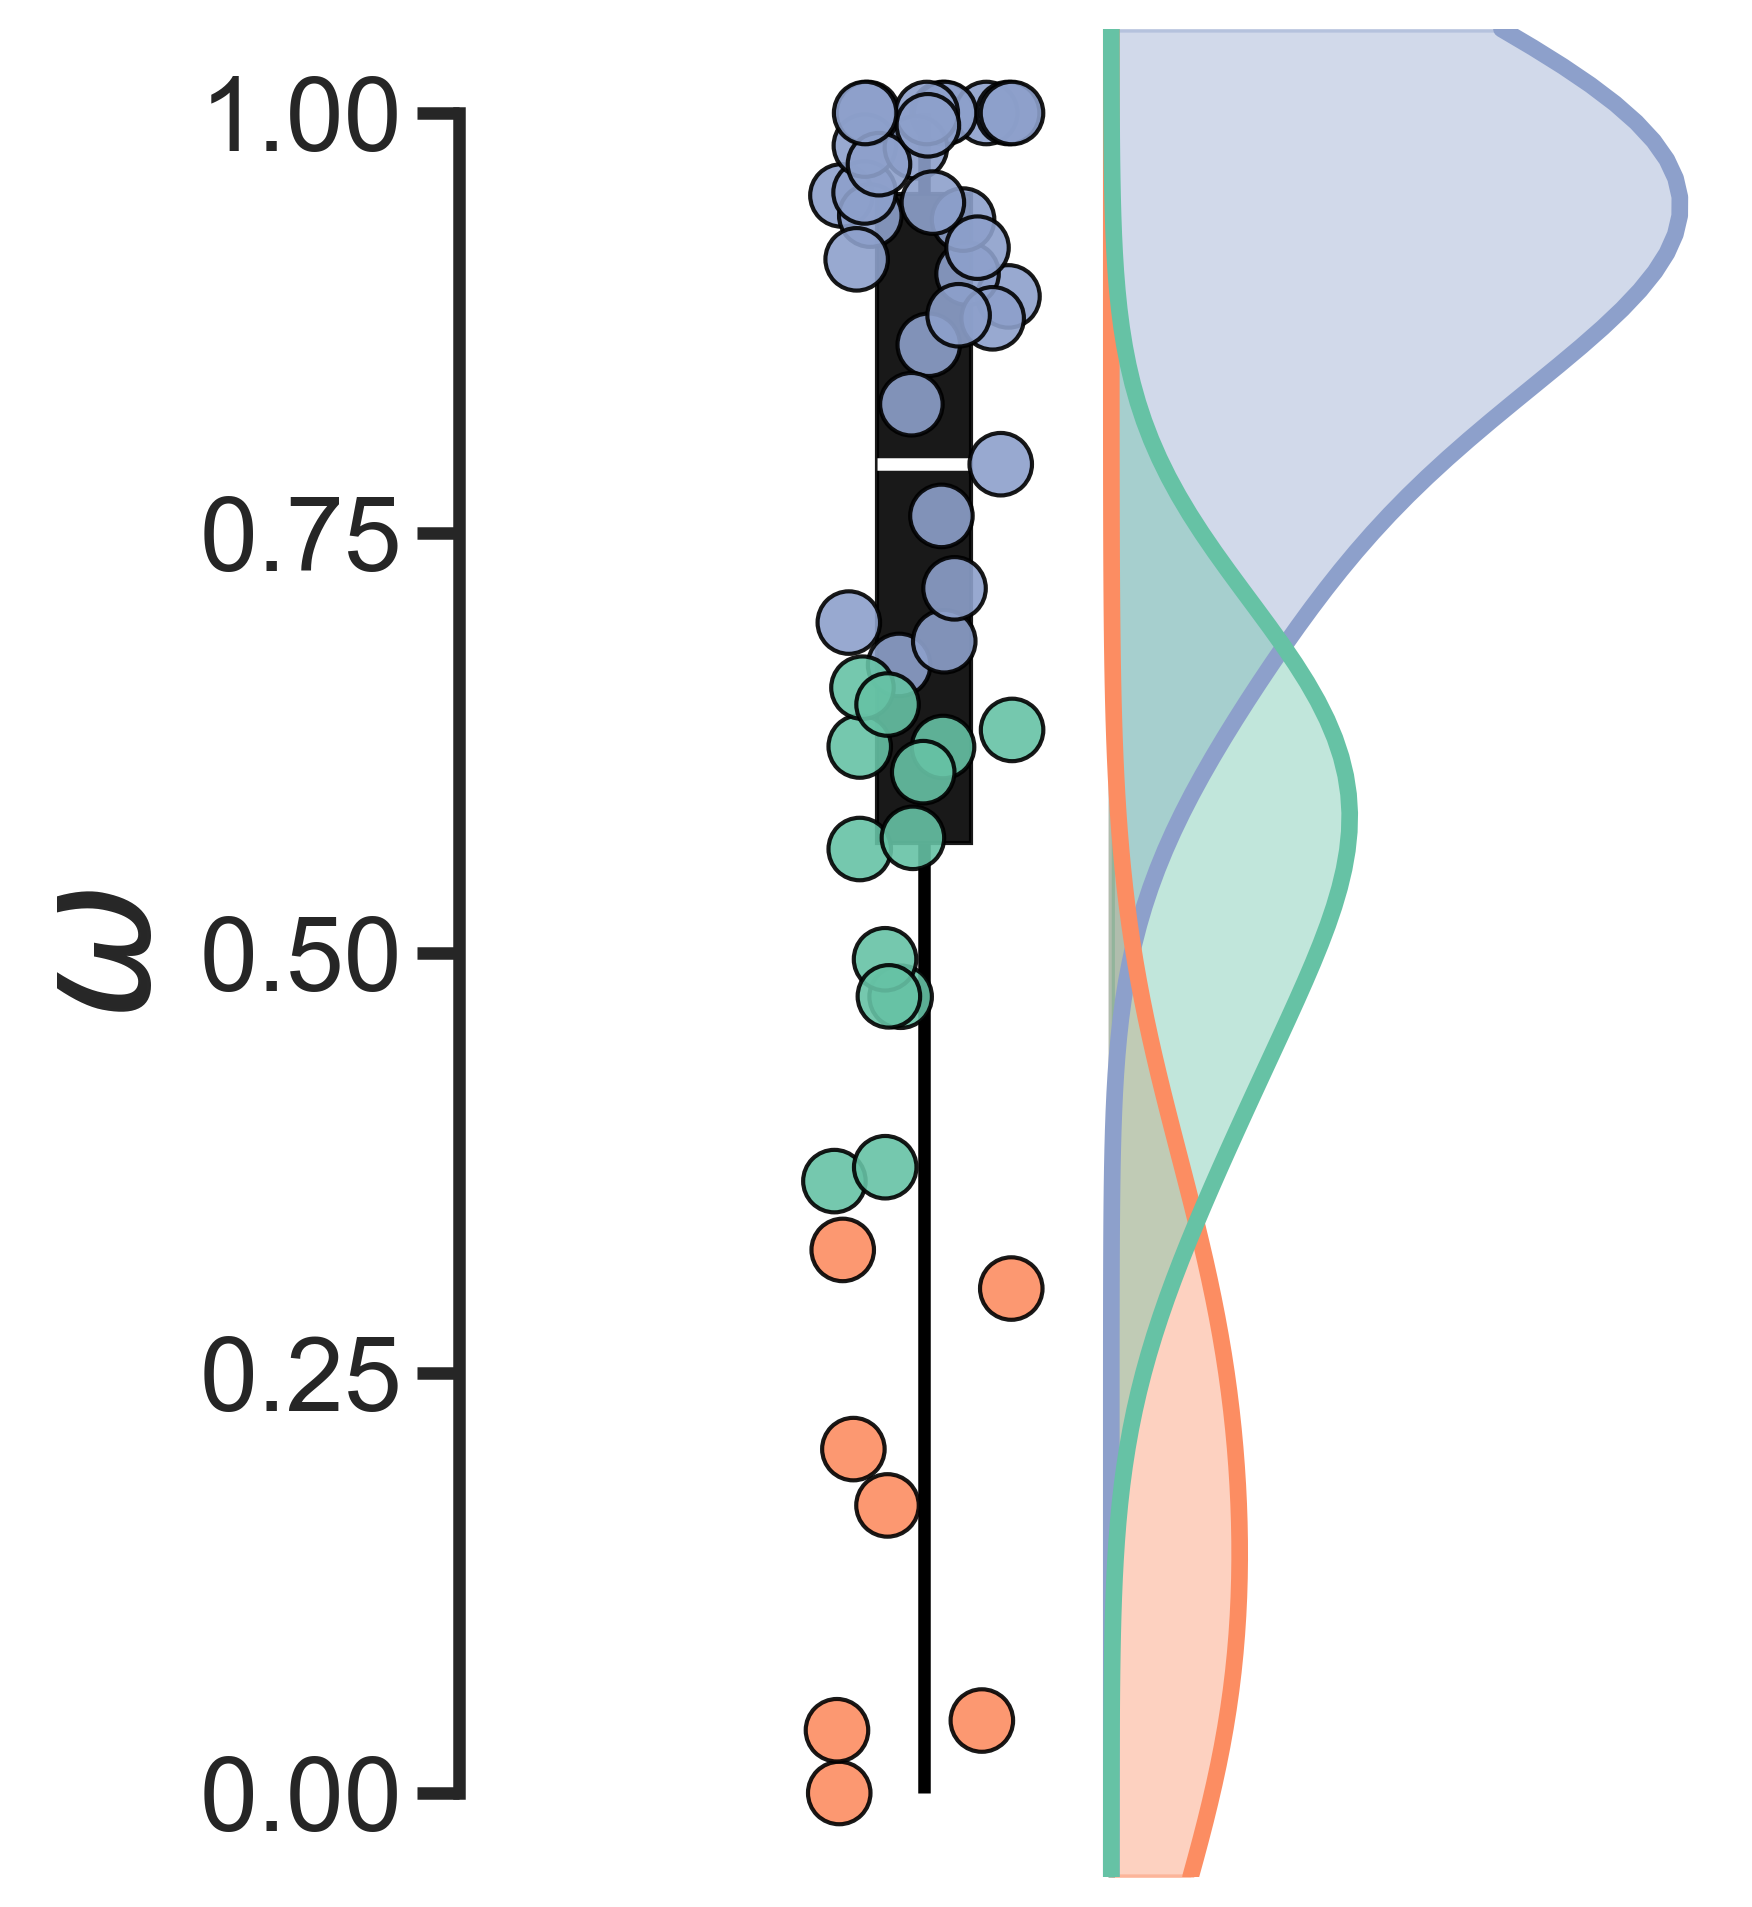

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

np.random.seed(42)

exp_ = 'FullPilot12'
delta = df_fit[(df_fit.model=='map') & (df_fit.exp==exp_) & (df_fit.group!='random')].groupby(['agent', 'group', 'model', 'exp']).last().reset_index()

dd2 = pd.DataFrame({
    'agent': delta.agent.values,
    'expName': delta.exp,
    'group': delta.group.values,
    'model': delta.model.values,
    'delta': delta.omega.values,
    'll': delta.ll.values,
})

dd2 = dd2[(dd2.expName==exp_) & (dd2.group.isin(['value', 'perceptual', 'combined']))]
groups = sorted(dd2.group.unique(), key=lambda x: ['perceptual', 'value', 'combined'].index(x))

palette = sns.color_palette('Set2')
palette = [palette[2], palette[1], palette[0]]
dot_position = -.5
kde_start = 0.2

sns.set_style('ticks')
sns.set_context('talk')
plt.figure(figsize=(4, 8), dpi=300)

sns.boxplot(y='delta', data=dd2, color='black', width=0.1, x=np.ones(len(dd2))*dot_position,
            boxprops=dict(facecolor='black', zorder=1, alpha=0.9),
            whiskerprops=dict(color='black', zorder=1, linewidth=3),
            capprops=dict(color='black', zorder=1, linewidth=0),
            medianprops=dict(color='white', zorder=2, linewidth=3),
            showfliers=False,
            saturation=1,
            ax=plt.gca()
            )

sns.stripplot(data=dd2, x=np.ones(len(dd2))*dot_position, y='delta', hue='group',
              hue_order=groups, palette=palette,
              edgecolor='black', size=15, linewidth=1, alpha=0.9, zorder=2)

plt.ylim(-.05, 1.05)

x_pts = np.linspace(dd2.delta.min() - 0.05, dd2.delta.max() + 0.05, 100)
overall_kde = stats.gaussian_kde(dd2['delta'].values, bw_method=1)
overall_density = overall_kde(x_pts)
max_overall_density = overall_density.max()

for i, group_name in enumerate(groups):
    subset = dd2[dd2.group == group_name]
    group_kde = stats.gaussian_kde(subset['delta'].values, bw_method=1)
    group_density = group_kde(x_pts)
    scaled_density = (group_density / group_density.max()) * len(subset) / len(dd2) * max_overall_density**0.1
    plt.fill_betweenx(x_pts, kde_start, kde_start + scaled_density, color=palette[i], alpha=0.4)
    plt.plot(kde_start + scaled_density, x_pts, color=palette[i], lw=4)

plt.xticks([], [])
plt.yticks(np.arange(0, 1.1, .25), fontsize=40)
plt.legend().remove()

sns.despine(trim=True, bottom=True, offset=80)
plt.xlabel('')
plt.ylabel('$\\omega$', fontdict={'fontsize': 40})
plt.yticks(fontsize=25)
plt.gca().spines['left'].set_linewidth(3)
plt.gca().tick_params(width=3, length=10)


C:\Users\basil\AppData\Local\Temp\ipykernel_38612\944777076.py:23: UserWarning: 
The palette list has fewer values (3) than needed (4) and will cycle, which may produce an uninterpretable plot.
  sns.kdeplot(data=df_, x='opti_ss', y='opti_ff', alpha=0.15, fill=True, palette=['C2', 'C0', 'C1'], hue='group', levels=2, bw_adjust=0.6, thresh=0.001)
C:\Users\basil\AppData\Local\Temp\ipykernel_38612\944777076.py:26: UserWarning: 
The palette list has fewer values (3) than needed (4) and will cycle, which may produce an uninterpretable plot.
  scatter = sns.scatterplot(data=df_, x='opti_ss', y='opti_ff', hue='group', palette=['C2', 'C0', 'C1'], s=100


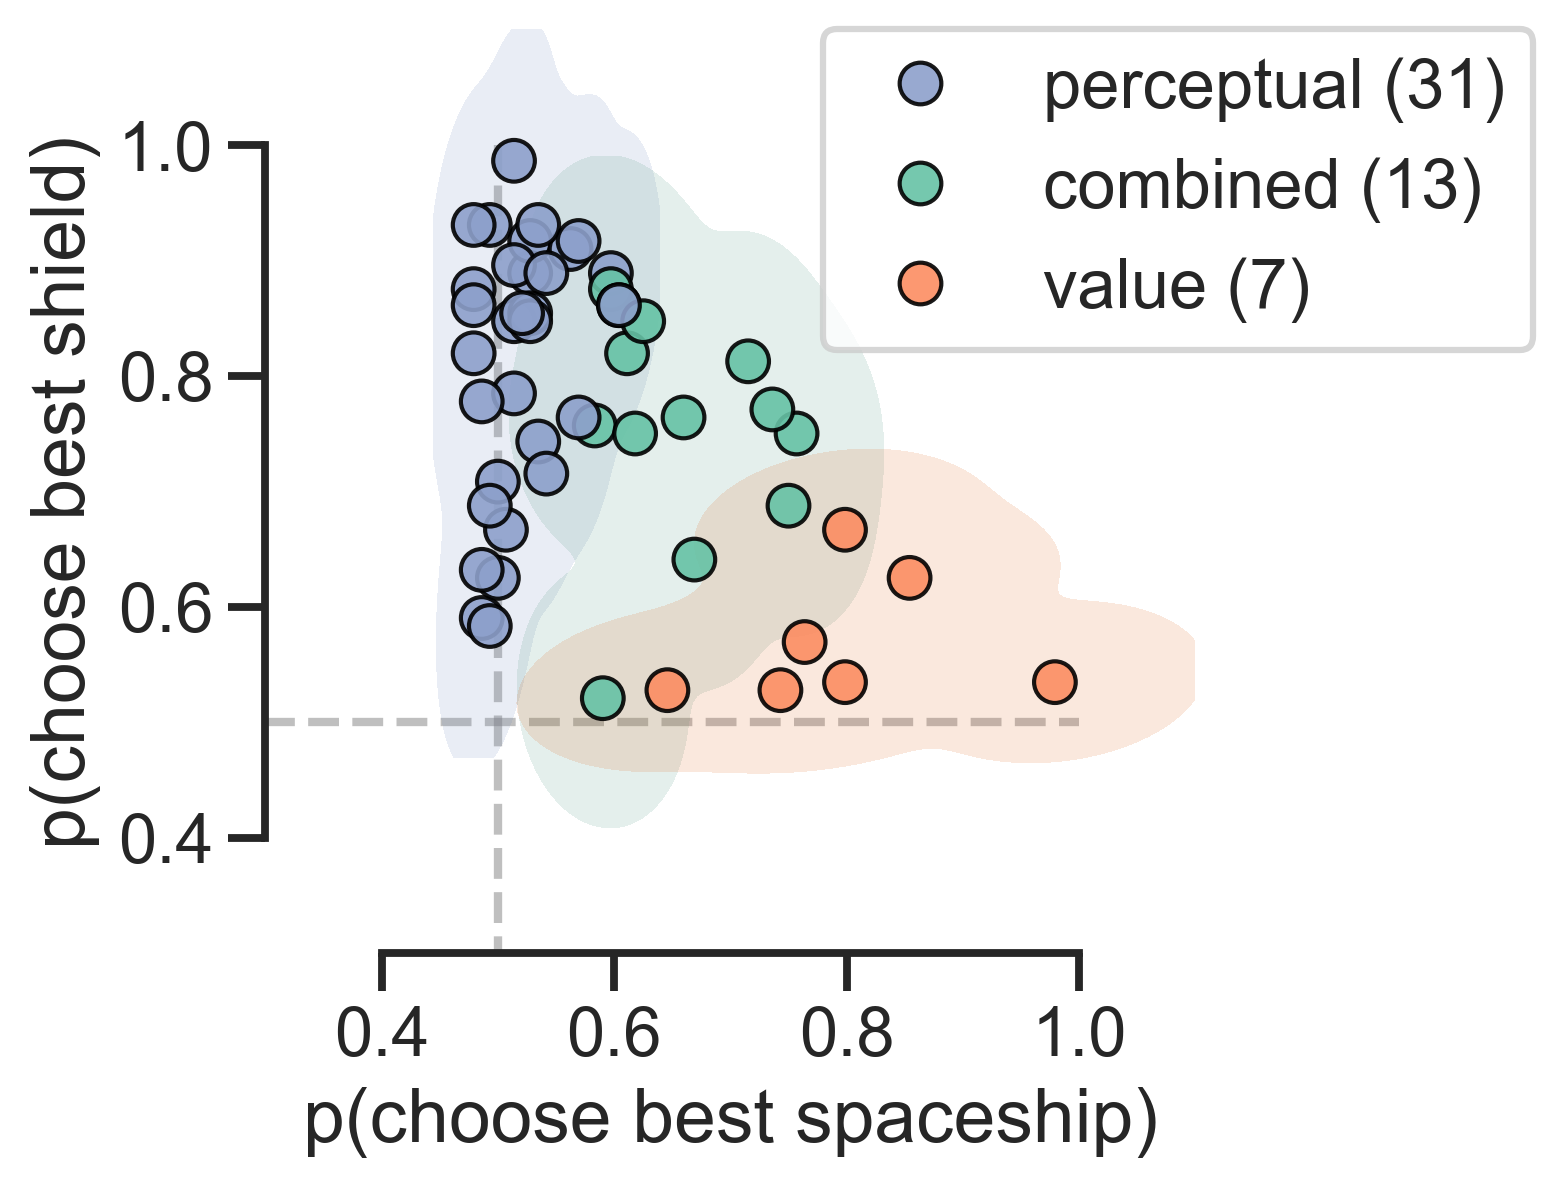

In [4]:
# same but with scatterplot

import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

df_ = df[(df.session==3) & (df.pair.isin([0,1])) & (df.group!='random') & (df.expName=='FullPilot12')].groupby(['prolificID', 'group'], as_index=False).mean(numeric_only=True)
# df_ = df_[df_.group!='random']
sns.set(rc={'figure.figsize':(4,4), 'figure.dpi': 300})
sns.set_context("talk")
sns.set_style("ticks")
sns.set_palette('Set2')

# sort by group 
order = ['perceptual', 'combined', 'value', 'random']
df_['group'] = pd.Categorical(df_['group'], categories=order, ordered=True)

# df_['opti_ss_training'] = df[(df.expName=='FullPilot14') & (df.session==2) & (df.group!='random')].groupby(['prolificID', 'group']).opti_ss.mean().values
# df_['opti_ff_training'] = df[(df.expName=='FullPilot14') & (df.session==1) & (df.group!='random')].groupby(['prolificID', 'group']).opti_ff.mean().values



# using seaborn, we want a region of interest using the colors of the clusters in scatterplot
sns.kdeplot(data=df_, x='opti_ss', y='opti_ff', alpha=0.15, fill=True, palette=['C2', 'C0', 'C1'], hue='group', levels=2, bw_adjust=0.6, thresh=0.001) 
# Draw kdeplot for clusters with sufficient points

scatter = sns.scatterplot(data=df_, x='opti_ss', y='opti_ff', hue='group', palette=['C2', 'C0', 'C1'], s=100
, edgecolor='black', linewidth=1, alpha=0.9)

            

# add a third dimension (opti_ev)
plt.ylim(0.3, 1.1)
plt.xlim(0.3, 1.1)

# add identity line (x=y)
# plt.plot([0.3, 1], [0.3, 1], color='grey', lw=2, zorder=-100, alpha=0.5)

# add 0.5 line v and h
# plt.axhline(0.5, color='grey', lw=2, ls='--', alpha=0.5, zorder=-100)
# plt.axvline(0.5, color='grey', lw=2, ls='--', alpha=0.5 , zorder=-100)

plt.plot([0, 1], [.5, .5], color='grey', lw=2, ls='--', alpha=0.5, zorder=-100)
plt.plot([.5, .5], [0, 1], color='grey', lw=2, ls='--', alpha=0.5, zorder=-100)

plt.xlabel('p(choose best spaceship)')
plt.ylabel('p(choose best shield)')
# put legend outside
# N = len(data)
# plt.title(f'counterfactual+R/2; N={N}')
sns.despine(trim=True)
#no legend
# plt.legend().remove()

#
# use order for legend
handles, labels = plt.gca().get_legend_handles_labels()
labels = ['perceptual', 'combined', 'value']
handles = [handles[order.index(label)] for label in labels]
labels = [f'{label} ({len(df_[df_.group==label])})' for label in labels]
plt.legend(title='', bbox_to_anchor=(0.6, 1), labels=labels, handles=handles,
           loc=2, borderaxespad=0.)

# legend order
# plt.legend().remove()

# RISK
normative model = risky at .75 frequency


In [5]:
# load risk tests
#select prolificIDs
dd = df[(df.expName=='FullPilot12_2') & (df.session==3) & (df.pair.isin([0,1]))]
pids = dd.prolificID.unique()

# now go get these prolificIDs from the risk tests
dospert = pd.read_csv('../data/raw/test/spaceprl_dospert(5).csv')
dospert = dospert[dospert.prolificID.isin(pids)]
# general = pd.read_csv('../data/raw/test/spaceprl_general_risk(2).csv')
# general = general[general.prolificID.isin(pids)]
feed = pd.read_csv('../data/raw/test/spaceprl_feedback(1).csv')
feed = feed[feed.prolificID.isin(pids)]
lot = pd.read_csv('../data/raw/test/spaceprl_risk(4).csv')
lot = lot[lot.prolificID.isin(pids)]

# lot is a holt and laury test with 10 choices (choice_0 to choice_9)
# compute risky choices
lot['risky_choices'] = lot[[f'choice_{i}' for i in range(10)]].sum(axis=1)
# lot = lot[['prolificID', 'risky_choices', 'amount']]
# compute dospert risk score as the sum of all columns except prolificID
dospert['risk_d'] = dospert[[f'q{i}' for i in range(0, 30)]].sum(axis=1)

# compute the average of q0 to q5 if the columns exist
# first map Strongly Disagree to 1, Disagree to 2, Neutral to 3, Agree to 4, Strongly Agree to 5
feed = feed.replace({'Strongly Disagree': 5, 'Disagree': 4, 'Neutral': 3, 'Agree': 2, 'Strongly Agree': 1})
# then compute the mean of q0 to q3 if the columns exist
feed['feedback'] = feed[[f'q{i}' for i in [0,1,2,3,4]]].mean(axis=1) / 5
# for participant that have NaN in q3 and q4, take q2 value, for the reste take q3 value
# feed['feedback'] = np.where(feed.q3.isna() & feed.q2.notna(), feed.q2, feed.q3)
# for participant that have NaN in q3 and q2, take mean of q0 and q1 value, for the reste take q0 to q2 value
# feed['feedback'] = np.where(feed.q3.isna() & feed.q2.isna(), feed[[f'q{i}' for i in [0,1]]].mean(axis=1), feed[[f'q{i}' for i in [0,1,2]]].mean(axis=1))
# finally, if feedback is NaN, replace it with the mean of the feedback
# create a new df called risk 
risk = pd.merge(lot, dospert, on='prolificID', how='outer')
risk = pd.merge(risk, feed[['prolificID', 'feedback']], on='prolificID', how='outer')
# add the chose_risky avg from dd to risk
risk = pd.merge(risk, df[df.expName.isin(['FullPilot12_2']) & (df.session==3) & (df.pair.isin([0,1]))].groupby('prolificID').chose_risky.mean().reset_index(), on='prolificID', how='left')
risk = pd.merge(risk, df[df.expName.isin(['FullPilot12_2']) & (df.session==3) & (df.pair.isin([0,1]))].groupby('prolificID').chose_safe.mean().reset_index(), on='prolificID', how='left')
# also add opti_ff
risk = pd.merge(risk, df[df.expName.isin(['FullPilot12_2']) & (df.session==3) & (df.pair.isin([0,1]))].groupby('prolificID').opti_ff.mean().reset_index(), on='prolificID', how='left')
# also add opti_ss
risk = pd.merge(risk, df[df.expName.isin(['FullPilot12_2']) & (df.session==3) & (df.pair.isin([0,1]))].groupby('prolificID').opti_ss.mean().reset_index(), on='prolificID', how='left')
risk = pd.merge(risk, df[df.expName.isin(['FullPilot12_2']) & (df.session==3) & (df.pair.isin([0,1]))].groupby('prolificID').opti_ev.mean().reset_index(), on='prolificID', how='left')
# remove 65707ef834f5c6af96da98ce
risk = risk[risk.prolificID != '65707ef834f5c6af96da98ce']

risk = pd.merge(risk, df[df.expName.isin(['FullPilot12_2']) & (df.session==3) & (df.pair.isin([0,1]))].groupby('prolificID').group.first().reset_index(), on='prolificID', how='left')

df_fit = pd.read_csv('../data/processed/omega_fit_full.csv')
risk['omega'] = df_fit[(df_fit.prolificID.isin(risk.prolificID))].groupby('prolificID').omega.last().reset_index(drop=True)
risk['beta'] = df_fit[df_fit.prolificID.isin(risk.prolificID)].groupby('prolificID').beta.last().reset_index(drop=True)

C:\Users\basil\AppData\Local\Temp\ipykernel_38612\4012201619.py:25: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  feed = feed.replace({'Strongly Disagree': 5, 'Disagree': 4, 'Neutral': 3, 'Agree': 2, 'Strongly Agree': 1})


In [6]:
# melt lot into a new df called lot_melted with columns prolificID, choice, choice_number
lot_melted = pd.melt(lot, id_vars=['prolificID'], value_vars=[f'choice_{i}' for i in range(10)], var_name='choice_number', value_name='choice')
# convert choice_number to int 
lot_melted['choice_number'] = lot_melted['choice_number'].str.replace('choice_', '').astype(int)

risk['dospert'] = risk['risk_d'] / (30 * 7)


N= 51


c:\Users\basil\.pyenv\pyenv-win\versions\3.9.12\lib\site-packages\raincloudpy\raincloud.py:161: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


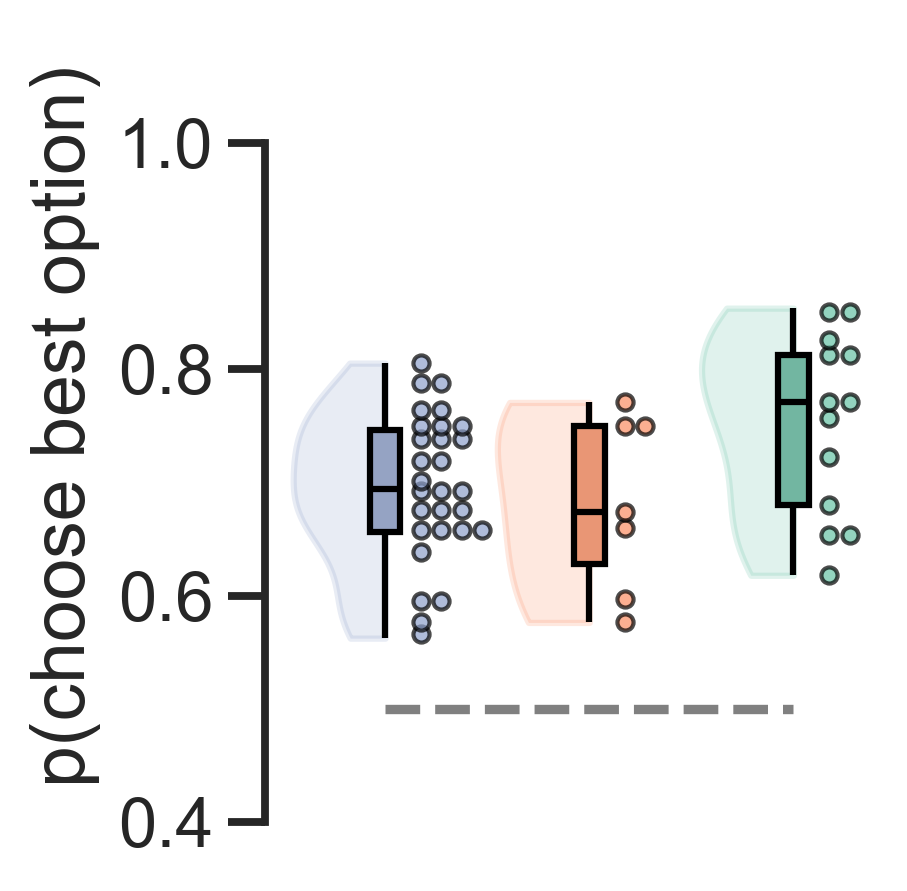

In [7]:
# compare opti_ss mean in session 2 to opti_ff_mean in session 2


ddf = df.copy()
# ddf = ddf[ddf.group!='random']
# ddf = ddf[ddf.t>23] 
ddf = ddf[ddf.session.isin([3]) & (ddf.pair.isin([0,1])) & (ddf.group!='random')]
ddf = ddf[ddf.expName.isin(['FullPilot12'])]
ddf = ddf.groupby(['prolificID', 'group'], as_index=False).mean(numeric_only=True)
# ddf['rt'] = df[(df.session==3) & (df.pair.isin([0,1])) & (df.group!='random') & (df.expName.isin(['FullPilot12_2']))].groupby('prolificID').fireTime.mean().reset_index(drop=True)

print('N=',ddf.prolificID.nunique())

plt.figure(figsize=(3, 3), dpi=300)
sns.set_style('ticks')
sns.set_context('talk')
sns.set_palette('Set2')
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from raincloudpy import raincloudplot
# plt.plot([0, 2], [0.5, 0.5], color='grey', linestyle='--', zorder=-1000)

raincloudplot(
    x='group', y='opti_ev', data=ddf, palette=['C2', 'C1', 'C0'],
    dot_size=15, dot_spacing=0.1,
    box_kwargs={'color':'black', 'linecolor': 'black', 'linewidth':1.5},
    box_dots_spacing=0.1, y_threshold=0.01, violin_width=0.45, order=['perceptual', 'value', 'combined']
)

plt.plot([0, 1, 2], [0.5, 0.5, 0.5], color='grey', linestyle='--', zorder=-1000)


plt.ylim(0.4, 1.1)
# plt.yticks(np.linspace(0, 1, 6))
plt.xlabel('')
plt.xticks([])

plt.ylabel('p(choose best option)')
sns.despine(trim=True, bottom=True)

# Remove tight_layout() completely
# plt.tight_layout()

# Use subplots_adjust with a LARGER left margin
plt.gcf().subplots_adjust(left=0.30, right=0.98, top=0.98, bottom=0.10)


In [8]:
# check that opti_ev is sig. different across groups
import pingouin as pg

ev = pg.pairwise_tests(data=ddf, dv='opti_ev', between='group', parametric=True, padjust='bonf', correction='bonferroni', 
                  effsize='cohen')

# # now add confidence intervals for independent t-test between perceptual and value groups
import itertools as it
pairs = list(it.combinations(ddf.group.unique(), 2))

for pair in pairs:
    # print(f'CI for {pair[0]} vs {pair[1]}:')
    ci = pg.ttest(
        ddf[ddf.group==pair[0]].opti_ev.values,
        ddf[ddf.group==pair[1]].opti_ev.values,
        confidence=0.95, correction='bonferroni')['CI95%']
    # now add to ev dataframe
    ev.loc[(ev['A']==pair[0]) & (ev['B']==pair[1]), 'CI95%'] = str(ci.values[0])

print(ev)



  Contrast           A           B  Paired  Parametric         T   dof  \
0    group    combined  perceptual   False        True  2.629124  42.0   
1    group    combined       value   False        True  1.883663  18.0   
2    group  perceptual       value   False        True  0.244996  36.0   

  alternative     p-unc    p-corr p-adjust   BF10     cohen          CI95%  
0   two-sided  0.011909  0.035728     bonf  4.324  0.868730    [0.01 0.11]  
1   two-sided  0.075870  0.227610     bonf  1.312  0.883075  [-0.01  0.15]  
2   two-sided  0.807851  1.000000     bonf  0.388  0.102523  [-0.05  0.07]  


N= 51


c:\Users\basil\.pyenv\pyenv-win\versions\3.9.12\lib\site-packages\raincloudpy\raincloud.py:161: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


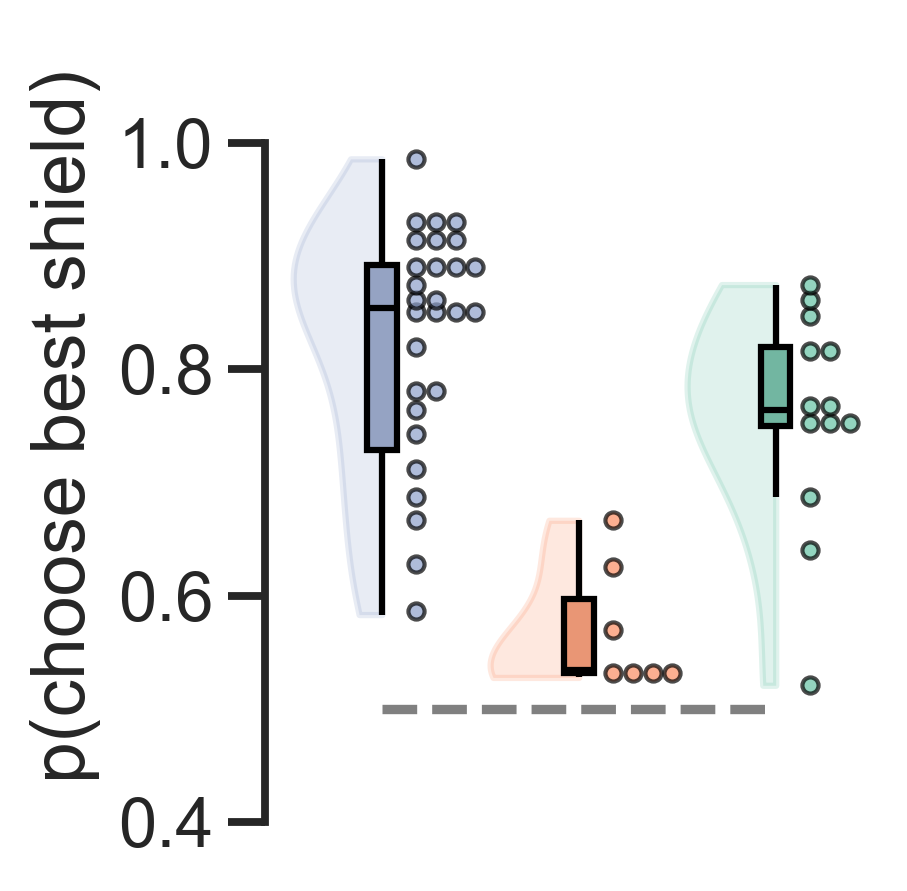

In [9]:
# compare opti_ss mean in session 2 to opti_ff_mean in session 2


ddf = df.copy()
# ddf = ddf[ddf.group!='random']
# ddf = ddf[ddf.t>23] 
ddf = ddf[ddf.session.isin([3]) & (ddf.pair.isin([0,1])) & (ddf.group!='random')]
ddf = ddf[ddf.expName.isin(['FullPilot12'])]
ddf = ddf.groupby(['prolificID', 'group'], as_index=False).mean(numeric_only=True)
# ddf['rt'] = df[(df.session==3) & (df.pair.isin([0,1])) & (df.group!='random') & (df.expName.isin(['FullPilot12_2']))].groupby('prolificID').fireTime.mean().reset_index(drop=True)

print('N=',ddf.prolificID.nunique())

plt.figure(figsize=(3, 3), dpi=300)
sns.set_style('ticks')
sns.set_context('talk')
sns.set_palette('Set2')
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from raincloudpy import raincloudplot
# plt.plot([0, 2], [0.5, 0.5], color='grey', linestyle='--', zorder=-1000)
var = 'opti_ff'
raincloudplot(
    x='group', y=var, data=ddf, palette=['C2', 'C1', 'C0'],
    dot_size=15, dot_spacing=0.1,
    box_kwargs={'color':'black', 'linecolor': 'black', 'linewidth':1.5},
    box_dots_spacing=0.1, y_threshold=0.01, violin_width=0.45, order=['perceptual', 'value', 'combined']
)

plt.plot([0, 1, 2], [0.5, 0.5, 0.5], color='grey', linestyle='--', zorder=-1000)


plt.ylim(0.4, 1.1)
# plt.yticks(np.linspace(0, 1, 6))
plt.xlabel('')
plt.xticks([])

plt.ylabel('p(choose best shield)')
sns.despine(trim=True, bottom=True)

# Remove tight_layout() completely
# plt.tight_layout()

# Use subplots_adjust with a LARGER left margin
plt.gcf().subplots_adjust(left=0.30, right=0.98, top=0.98, bottom=0.10)


In [10]:
# check that opti_ev is sig. different across groups
import pingouin as pg

ev = pg.pairwise_tests(data=ddf, dv='opti_ff', between='group', parametric=True, padjust='bonf', correction='bonferroni', 
                  effsize='cohen')

# # now add confidence intervals for independent t-test between perceptual and value groups
import itertools as it
pairs = list(it.combinations(ddf.group.unique(), 2))

for pair in pairs:
    # print(f'CI for {pair[0]} vs {pair[1]}:')
    ci = pg.ttest(
        ddf[ddf.group==pair[0]].opti_ff.values,
        ddf[ddf.group==pair[1]].opti_ff.values,
        confidence=0.95, correction='bonferroni')['CI95%']
    # now add to ev dataframe
    ev.loc[(ev['A']==pair[0]) & (ev['B']==pair[1]), 'CI95%'] = str(ci.values[0])

print(ev)



  Contrast           A           B  Paired  Parametric         T   dof  \
0    group    combined  perceptual   False        True -1.512435  42.0   
1    group    combined       value   False        True  4.687999  18.0   
2    group  perceptual       value   False        True  5.528949  36.0   

  alternative     p-unc    p-corr p-adjust      BF10     cohen          CI95%  
0   two-sided  0.137912  0.413736     bonf     0.774 -0.499748  [-0.13  0.02]  
1   two-sided  0.000183  0.000550     bonf   115.365  2.197768    [0.1  0.27]  
2   two-sided  0.000003  0.000009     bonf  3919.478  2.313687    [0.15 0.33]  


N= 51


c:\Users\basil\.pyenv\pyenv-win\versions\3.9.12\lib\site-packages\raincloudpy\raincloud.py:161: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


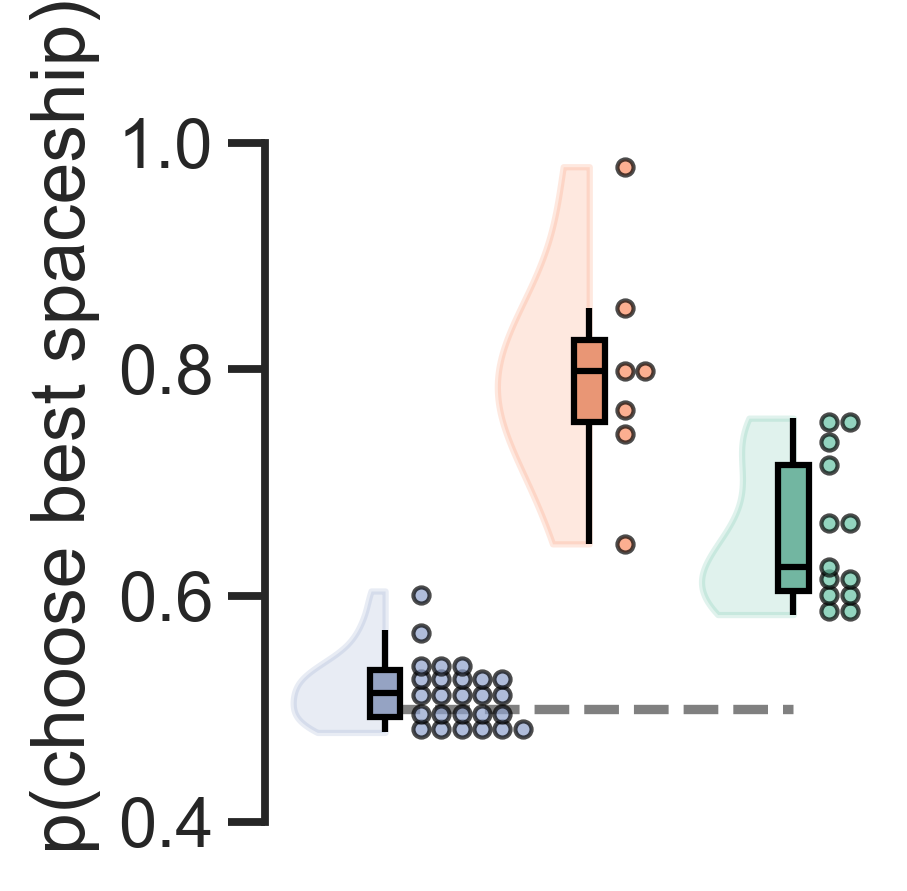

In [11]:
# compare opti_ss mean in session 2 to opti_ff_mean in session 2


ddf = df.copy()
# ddf = ddf[ddf.group!='random']
# ddf = ddf[ddf.t>23] 
ddf = ddf[ddf.session.isin([3]) & (ddf.pair.isin([0,1])) & (ddf.group!='random')]
ddf = ddf[ddf.expName.isin(['FullPilot12'])]
ddf = ddf.groupby(['prolificID', 'group'], as_index=False).mean(numeric_only=True)
# ddf['rt'] = df[(df.session==3) & (df.pair.isin([0,1])) & (df.group!='random') & (df.expName.isin(['FullPilot12_2']))].groupby('prolificID').fireTime.mean().reset_index(drop=True)

print('N=',ddf.prolificID.nunique())

plt.figure(figsize=(3, 3), dpi=300)
sns.set_style('ticks')
sns.set_context('talk')
sns.set_palette('Set2')
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from raincloudpy import raincloudplot
# plt.plot([0, 2], [0.5, 0.5], color='grey', linestyle='--', zorder=-1000)

var = 'opti_ss'

raincloudplot(
    x='group', y=var, data=ddf, palette=['C2', 'C1', 'C0'],
    dot_size=15, dot_spacing=0.1,
    box_kwargs={'color':'black', 'linecolor': 'black', 'linewidth':1.5},
    box_dots_spacing=0.1, y_threshold=0.01, violin_width=0.45, order=['perceptual', 'value', 'combined']
)

plt.plot([0, 1, 2], [0.5, 0.5, 0.5], color='grey', linestyle='--', zorder=-1000)


plt.ylim(0.4, 1.1)
# plt.yticks(np.linspace(0, 1, 6))
plt.xlabel('')
plt.xticks([])

plt.ylabel('p(choose best spaceship)')
sns.despine(trim=True, bottom=True)

# Remove tight_layout() completely
# plt.tight_layout()

# Use subplots_adjust with a LARGER left margin
plt.gcf().subplots_adjust(left=0.30, right=0.98, top=0.98, bottom=0.10)


In [12]:
# check that opti_ev is sig. different across groups
import pingouin as pg

ev = pg.pairwise_tests(data=ddf, dv='opti_ss', between='group', parametric=True, padjust='bonf', correction='bonferroni', 
                  effsize='cohen')

# # now add confidence intervals for independent t-test between perceptual and value groups
import itertools as it
pairs = list(it.combinations(ddf.group.unique(), 2))

for pair in pairs:
    # print(f'CI for {pair[0]} vs {pair[1]}:')
    ci = pg.ttest(
        ddf[ddf.group==pair[0]].opti_ss.values,
        ddf[ddf.group==pair[1]].opti_ss.values,
        confidence=0.95, correction='bonferroni')['CI95%']
    # now add to ev dataframe
    ev.loc[(ev['A']==pair[0]) & (ev['B']==pair[1]), 'CI95%'] = str(ci.values[0])

print(ev)



  Contrast           A           B  Paired  Parametric          T   dof  \
0    group    combined  perceptual   False        True   9.174044  42.0   
1    group    combined       value   False        True  -3.843796  18.0   
2    group  perceptual       value   False        True -12.733750  36.0   

  alternative         p-unc        p-corr p-adjust       BF10     cohen  \
0   two-sided  1.378775e-11  4.136325e-11     bonf  3.786e+08  3.031340   
1   two-sided  1.189444e-03  3.568333e-03     bonf     25.533 -1.802000   
2   two-sided  6.751862e-15  2.025559e-14     bonf  4.316e+11 -5.328663   

           CI95%  
0    [0.11 0.17]  
1  [-0.22 -0.06]  
2  [-0.32 -0.23]  


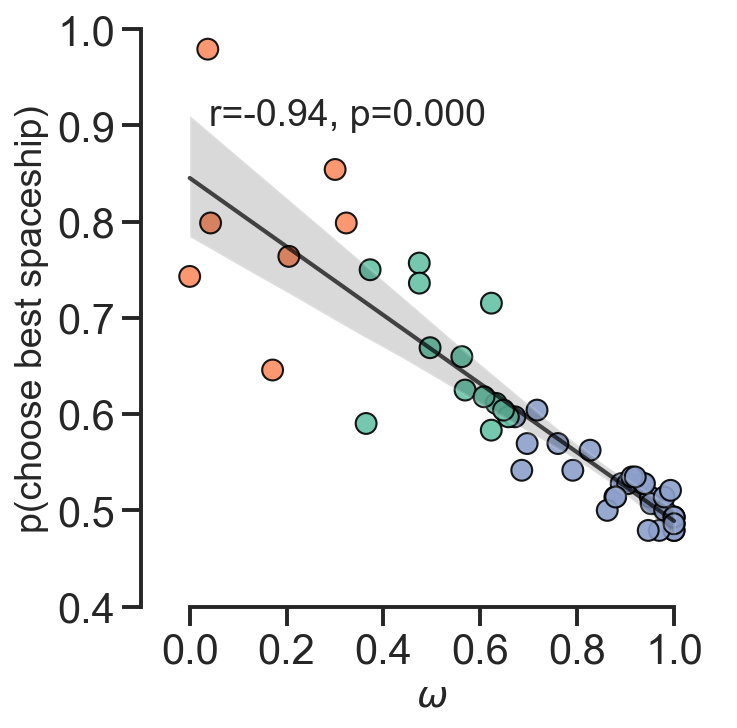

In [13]:
# get omega for FullPilot12

avg = df_fit[(df_fit.exp=='FullPilot12') & (df_fit.group!='random')]\
# sort by prolificID
avg = avg.sort_values('prolificID')
omega = avg.omega.values
group = avg.group.values

# get opti_ss for FullPilot12
opti_ss = df[(df.expName=='FullPilot12') & (df.session==3) & (df.pair.isin([0, 1])) & (df.group!='random')].groupby(['prolificID'])\
    .mean(numeric_only=True).sort_values('prolificID').reset_index().opti_ss.values
opti_ff = df[(df.expName=='FullPilot12') & (df.session==3) & (df.pair.isin([0, 1])) & (df.group!='random')].groupby(['prolificID'])\
    .mean(numeric_only=True).sort_values('prolificID').reset_index().opti_ff.values


# create a dataframe with omega and opti_ss
df_omega_opti = pd.DataFrame({
    'omega': omega,
    'opti_ff': opti_ff,
    'opti_ss': opti_ss,
    'group2': group
})

# change color of lmplot
colors = sns.color_palette("Set2")
sns.set({'figure.figsize': (5, 5), 'figure.dpi': 150})
sns.set_style('ticks')
sns.set_context('talk')
sns.set_palette('Set2')
# sns.set_palette([colors[1]])
sns.scatterplot(x='omega', y='opti_ss', data=df_omega_opti, hue='group2', palette=['C0', 'C2', 'C1'], s=100, edgecolor='black', linewidth=1, alpha=0.9)
plt.xlim(-0.1, 1.1)
plt.ylim(.4, 1)

# step is 0.2
plt.xticks(np.arange(0, 1.1, 0.2), fontsize=20)
plt.yticks(np.arange(0.4, 1.1, 0.1), fontsize=20)

# add the regression black line in the background
sns.regplot(x='omega', y='opti_ss', data=df_omega_opti, scatter=False, color='black', line_kws={'linewidth':2, 'alpha':0.7})
# pearson corr
import scipy.stats as stats

r, p = stats.spearmanr(df_omega_opti.omega, df_omega_opti.opti_ss)

plt.text(0.04, 0.9, f'r={r:.2f}, p={p:.3f}')

plt.xlabel('$\\omega$')
plt.ylabel('p(choose best spaceship)') 

sns.despine(trim=True,)
plt.legend().remove()

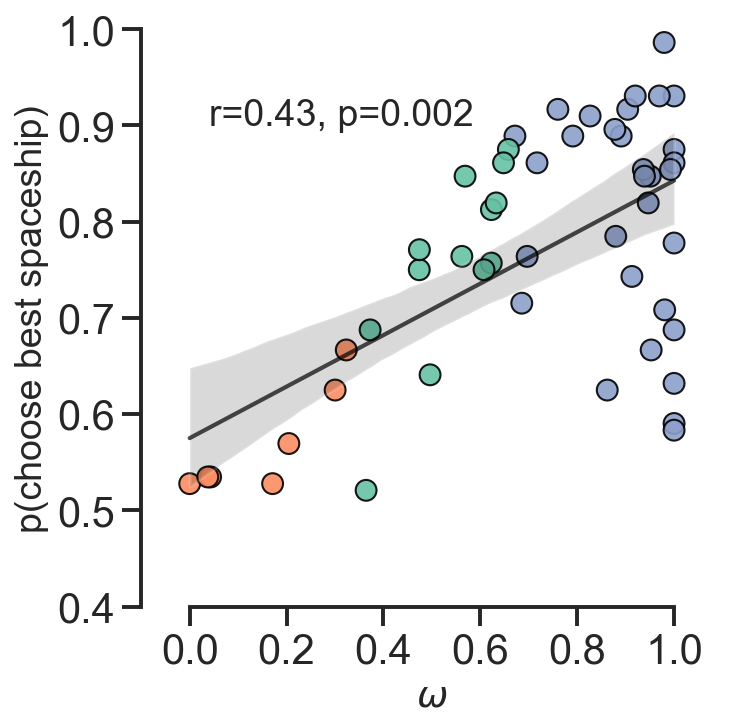

In [14]:

avg = df_fit[(df_fit.exp=='FullPilot12') & (df_fit.group!='random')]\
# sort by prolificID
avg = avg.sort_values('prolificID')
omega = avg.omega.values
group = avg.group.values

# get opti_ss for FullPilot12
opti_ss = df[(df.expName=='FullPilot12') & (df.session==3) & (df.pair.isin([0, 1])) & (df.group!='random')].groupby(['prolificID'])\
    .mean(numeric_only=True).sort_values('prolificID').reset_index().opti_ss.values
opti_ff = df[(df.expName=='FullPilot12') & (df.session==3) & (df.pair.isin([0, 1])) & (df.group!='random')].groupby(['prolificID'])\
    .mean(numeric_only=True).sort_values('prolificID').reset_index().opti_ff.values


# create a dataframe with omega and opti_ss
df_omega_opti = pd.DataFrame({
    'omega': omega,
    'opti_ff': opti_ff,
    'opti_ss': opti_ss,
    'group2': group
})

# change color of lmplot
colors = sns.color_palette("Set2")
sns.set({'figure.figsize': (5, 5), 'figure.dpi': 150})
sns.set_style('ticks')
sns.set_context('talk')
sns.set_palette('Set2')
# sns.set_palette([colors[1]])
sns.scatterplot(x='omega', y='opti_ff', data=df_omega_opti, hue='group2', palette=['C0', 'C2', 'C1'], s=100, edgecolor='black', linewidth=1, alpha=0.9)
plt.xlim(-0.1, 1.1)
plt.ylim(.4, 1)

# step is 0.2
plt.xticks(np.arange(0, 1.1, 0.2), fontsize=20)
plt.yticks(np.arange(0.4, 1.1, 0.1), fontsize=20)

# add the regression black line in the background
sns.regplot(x='omega', y='opti_ff', data=df_omega_opti, scatter=False, color='black', line_kws={'linewidth':2, 'alpha':0.7})
# pearson corr
import scipy.stats as stats

r, p = stats.spearmanr(df_omega_opti.omega, df_omega_opti.opti_ff)

plt.text(0.04, 0.9, f'r={r:.2f}, p={p:.3f}')

plt.xlabel('$\\omega$')
plt.ylabel('p(choose best spaceship)') 

sns.despine(trim=True,)
plt.legend().remove()